# Forest type mapping

## Task 1.

- Same data pre-processing steps

In [121]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('training.csv')
df_test = pd.read_csv('testing.csv')

column_headings = df_train.columns

#format your print, e.g.
print('Column headings are: ',column_headings)
print('training info', df_train.info())
# print('first 10', df_train.head())
print('\n')
print('test info', df_test.info())

Column headings are:  Index(['class', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9',
       'pred_minus_obs_H_b1', 'pred_minus_obs_H_b2', 'pred_minus_obs_H_b3',
       'pred_minus_obs_H_b4', 'pred_minus_obs_H_b5', 'pred_minus_obs_H_b6',
       'pred_minus_obs_H_b7', 'pred_minus_obs_H_b8', 'pred_minus_obs_H_b9',
       'pred_minus_obs_S_b1', 'pred_minus_obs_S_b2', 'pred_minus_obs_S_b3',
       'pred_minus_obs_S_b4', 'pred_minus_obs_S_b5', 'pred_minus_obs_S_b6',
       'pred_minus_obs_S_b7', 'pred_minus_obs_S_b8', 'pred_minus_obs_S_b9'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   class                325 non-null    object 
 1   b1                   325 non-null    int64  
 2   b2                   325 non-null    int64  
 3   b3                   325 non-null    int64  
 4   b4                 

In [122]:
from sklearn.model_selection import train_test_split

def clean_cols(df):
    return df[['class'] + [f'b{i}' for i in range (1,10)]]

# def remove_classes(df):
#     classes = ['s', 'd']
#     return df[df['class'].isin(classes)]

df_train = clean_cols(df_train)
df_test = clean_cols(df_test)

# df_train = remove_classes(df_train)
# df_test = remove_classes(df_test)

# df_train, df_valid = train_test_split(df_train, test_size=0.2, random_state=42)

x_train = df_train.drop(columns=['class'])
y_train = df_train['class']

# x_valid = df_valid.drop(columns=['class'])
# y_valid = df_valid['class']

x_test = df_test.drop(columns=['class'])
y_test = df_test['class']


print(x_train.info())
print(y_train.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 325 entries, 0 to 324
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   b1      325 non-null    int64
 1   b2      325 non-null    int64
 2   b3      325 non-null    int64
 3   b4      325 non-null    int64
 4   b5      325 non-null    int64
 5   b6      325 non-null    int64
 6   b7      325 non-null    int64
 7   b8      325 non-null    int64
 8   b9      325 non-null    int64
dtypes: int64(9)
memory usage: 23.0 KB
None
class
s    136
d    105
o     46
h     38
Name: count, dtype: int64


### Task 1
Apply feature scaling using the StandardScaler. Remember, you should fit the scalers using
the training set only, and the estimated parameters should be used to transform the training and
test sets.

In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
# x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

### Task 2

Use the Support Vector Machine Classifier implemented in the sklearn.svm.SVC class to
perform multiclass classification using the one-versus-one strategy. You should look at the Scikitlearn API for this class and experiment with two hyperparameters: C and kernel. You should use
Grid Search and 3-fold cross-validation to find the optimal values for these two hyperparameters
that maximise the classification accuracy. For other hyperparameters, you can use the API default
values.

In [124]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def model_helper(pipeline, param_grid):
    clf = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='f1_weighted',
        refit=True,
    )

    clf.fit(x_train, y_train)
    print(f'optimal hyperparameter values: {clf.best_params_}')

    cv_df = pd.DataFrame({
        'fold': range(1, 4),
        'Validation F1': [f'{clf.cv_results_[f"split{i}_test_score"][clf.best_index_]:.3f}' for i in range(3)]
    })

    print(cv_df.to_string(index=False) + '\n')

    train_accuracy = accuracy_score(y_train, clf.predict(x_train)) 
    test_accuracy = accuracy_score(y_test, clf.predict(x_test)) 

    print(f'Train accuracy: {train_accuracy:.3f}')
    print(f'Test accuracy: {test_accuracy:.3f}\n')

    ConfusionMatrixDisplay.from_estimator(
            clf,
            x_test,
            y_test,
            display_labels=clf.classes_,
        )
    plt.title('Test set')


### Task 3
What are the best values of these hyperparameters according to Grid Search? What is the performance in each of the validation folders using these values?

### Task 4
Train your model on the entire training set using these optimal values and inspect some performance indicators, such as:
(a) The accuracy in the training and test sets;
(b) The confusion matrix on the test set.

optimal hyperparameter values: {'svc__C': 1.0, 'svc__kernel': 'linear'}
 fold Validation F1
    1         0.889
    2         0.925
    3         0.868

Train accuracy: 0.911
Test accuracy: 0.889



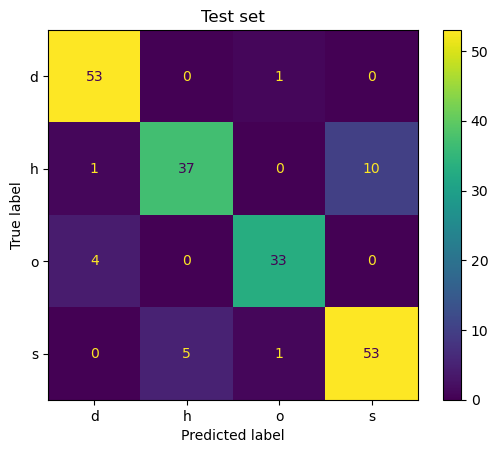

In [125]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

svc_scaled = model_helper(
    make_pipeline(StandardScaler(), SVC(decision_function_shape='ovo', random_state=42)),
    {'svc__C': np.logspace(-3,3,7), 'svc__kernel':['linear', 'rbf', 'poly', 'sigmoid'],}
)

### Task 5
Repeat the steps 2-4 process without doing feature scaling. Compare the results.



optimal hyperparameter values: {'svc__C': 0.01, 'svc__kernel': 'linear'}
 fold Validation F1
    1         0.880
    2         0.925
    3         0.859

Train accuracy: 0.905
Test accuracy: 0.904



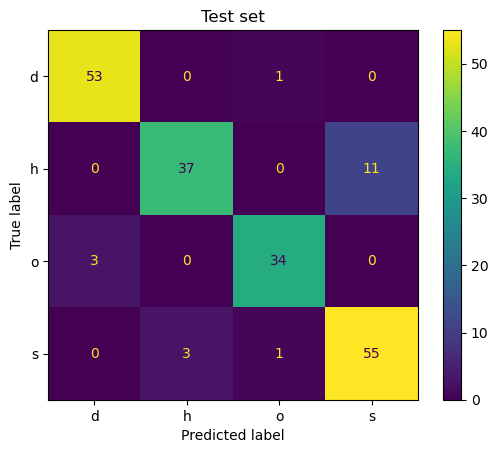

In [126]:
svc_unscaled = model_helper(
    make_pipeline(SVC(decision_function_shape='ovo', random_state=42)),
    {'svc__C': np.logspace(-3,3,7), 'svc__kernel':['linear', 'rbf', 'poly', 'sigmoid'],}
)

### Observation
- Performance is pretty similar but featured scaled version is much faster to fit.

## Task 6

- SVMs are sensitive to feature scaling, but `b1`, ..., `b9` are on similar scales already
- The quadratic programming problem is much faster to solve after scaling
- In this case we *can* skip feature scaling if we're careful, but it certainly doesn't hurt to do it.

### Task 7

Repeat tasks 1-4 using sklearn.linear model.LogisticRegression class to implement Softmax Regression. You should look at the Scikit-learn API for this class and experiment
with Grid Search and 3-fold cross-validation with two hyperparameters: penalty and C. Note
that C is the inverse of regularization strength for this class.

optimal hyperparameter values: {'logisticregression__C': 10.0, 'logisticregression__penalty': 'l2'}
 fold Validation F1
    1         0.889
    2         0.906
    3         0.850

Train accuracy: 0.911
Test accuracy: 0.914



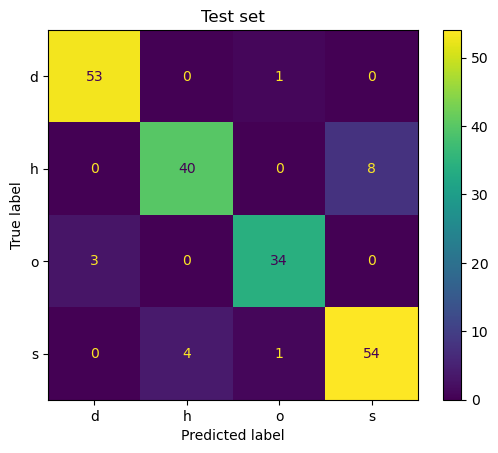

In [127]:
from sklearn.linear_model import LogisticRegression

# suppress warnings about penalty coefficients
import warnings
warnings.filterwarnings('ignore', message='Setting penalty=None will ignore the C and l1_ratio parameters')
warnings.filterwarnings('ignore', message="l1_ratio parameter is only used when penalty is 'elasticnet'.")

model_softmax = model_helper(
    make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=10000, random_state=42, l1_ratio=0.5, solver='saga')
    ),
    {
        'logisticregression__C': np.logspace(-3, 3, 7),
        'logisticregression__penalty': [None, 'l1', 'l2', 'elasticnet'],
    },
)

### 8 
Repeat tasks 1-4 using the K-NN algorithm. Again, your Grid Search should consider different
values of K and a 3-fold cross-validation

optimal hyperparameter values: {'kneighborsclassifier__n_neighbors': 10}
 fold Validation F1
    1         0.852
    2         0.885
    3         0.828

Train accuracy: 0.880
Test accuracy: 0.909



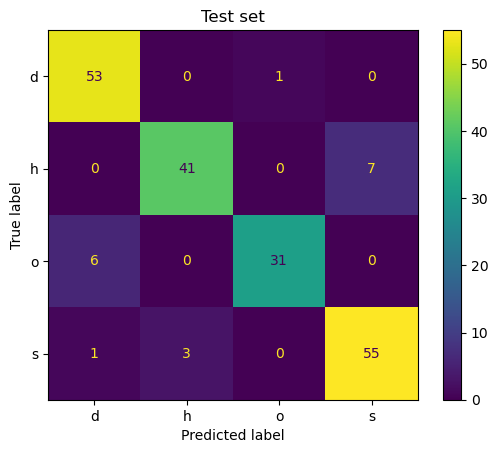

In [128]:
from sklearn.neighbors import KNeighborsClassifier

model_knn = model_helper(
    make_pipeline(StandardScaler(), KNeighborsClassifier()),
    {
        'kneighborsclassifier__n_neighbors': np.linspace(1, 50, 11, dtype=int)
    }
)